# Project 01: One protein against many ligands 

The purpose is to find **interaction hotspots** in a single target through the analysis of interactions found in a dataset of diverse small compounds.

This was used in the prototype pipeline to elucidate hotspots in the sars-cov-19 protease ([GH repo](https://github.com/volkamerlab/covid19-SBapproach)), and we will refine it here against other datasets.

## Content

* Data collection
    * Obtaining the data
    * Select fragment screen subset
    * Visual data inspection
* Generating proteil-ligand interaction statistics
    * Ingesting it in `plipify`
    *  Different display formats
* Generating 3D figures with interaction information

In [1]:
%load_ext autoreload
%autoreload 2

In [37]:
from pathlib import Path

import pandas as pd
from rdkit.Chem.PandasTools import AddMoleculeColumnToFrame

from urllib.request import urlopen
from io import BytesIO
from zipfile import ZipFile
from tqdm.auto import tqdm

import nglview as nv

from plipify.core import Structure
from plipify.fingerprints import InteractionFingerprint
from plipify.visualization import fingerprint_barplot, fingerprint_heatmap, fingerprint_table, fingerprint_nglview


# Data colletcion

In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data" / "XChem"
OUT = HERE / "output" / "XChem"
DATA.mkdir(exist_ok=True, parents=True)
OUT.mkdir(exist_ok=True, parents=True)

## Obtaining the data

We will be using data from [Diamond](https://www.diamond.ac.uk/), a XRC platform that generates structures for ligand/fragment collections against a given target. 

Back in early 2020, [this dataset](https://www.diamond.ac.uk/covid-19/for-scientists/Main-protease-structure-and-XChem.html) was released to help understand the CoViD-19 infection mechanism, focusing on the virus main protease **Mpro**. You can find more information about the Mpro structure and the XChem fragment screen [here](https://www.diamond.ac.uk/covid-19/for-scientists/Main-protease-structure-and-XChem.html).

An Excel file is available online, and will serve as a first introduction to the small compound library used.

,Dataset,Library Name,Compound SMILES,Modified Compound SMILES,Compound ID,Site,Confidence Annotation,Resolution (A),Occupancy estimate,Z-Peak,PDB Status,PDB Entry,Fragalysis,Zenodo Status,Unnamed: 14,ROMol
0,Mpro-x0072,DSIpoised_DMSO,CS(=O)(=O)NCCC=1C=CC=CC1,NaN,Z45617795,A - active,4 - High Confidence,1.65,0.40,5.37,Deposited,5R7Y,online,Deposited,NaN,
1,Mpro-x0104,DSIpoised_DMSO,CC(=O)NCCC1=CNC=2C=CC(F)=CC12,NaN,Z1220452176,A - active,"2 - Correct ligand, weak density",1.59,0.78,6.47,Deposited,5R7Z,online,Deposited,NaN,
2,Mpro-x0107,DSIpoised_DMSO,CC(=O)NC=1C=NC=CC1C,NaN,Z1129283193,A - active,4 - High Confidence,1.88,0.36,5.47,Deposited,5RE4,online,Deposited,NaN,
3,Mpro-x0161,DSIpoised_DMSO,COC(=O)C=1C=CC(=CC1)S(=O)(=O)N,NaN,Z18197050,A - active,4 - High confidence,1.93,0.86,11.98,Deposited,5R80,online,Deposited,NaN,
4,Mpro-x0165,DSIpoised_DMSO,CN1CCN(CC1)C(=O)NC=2C=CC=CC2,NaN,Z2856434890,X - xtal contact (S81),"2 - Correct ligand, weak density",2.26,0.38,6.87,Deposited,5RGG,online,NaN,NaN,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,Mpro-x1493,Cysteine Covalent Library (Weizmann Institute),CC(=O)N1CCN(CC1)C(=O)CCl,CC(=O)N1CCN(CC1)C(=O)C,PCM-0102535,B - active - covalent,4 - High Confidence,1.72,0.33,5.46,Deposited,5RG0,online,Deposited,NaN,
91,Mpro-x2052,Cysteine Covalent Library (Weizmann Institute),O=C(C1CCN(C(CCl)=O)CC1)NC2=CC=C(OC)N=C2,COC1=CC=C(NC(=O)C2CCN(CC2)C(C)=O)C=N1,PG-COV-42,B - active - covalent,"2 - Correct ligand, weak density",1.56,0.38,4.82,Deposited,5RHE,online,NaN,NaN,
92,Mpro-x2097,Electrophilic Heterocycles (Gyorgy Keseru),N#CC1=NC=CC=N1,N=CC1=NC=CC=N1,Cov_HetLib 030,B - active - covalent,4 - High Confidence,1.43,0.80,6.22,Deposited,5RHB,online,NaN,NaN,
93,Mpro-x2119,Electrophilic Heterocycles (Gyorgy Keseru),N#CC1=NC=CN1,N=CC1=NC=CN1,Cov_HetLib 053,B - active - covalent,4 - High Confidence,1.58,0.80,6.26,Deposited,5RHC,online,NaN,NaN,

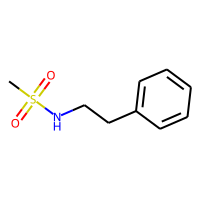
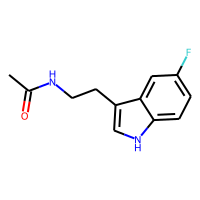
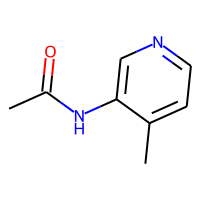
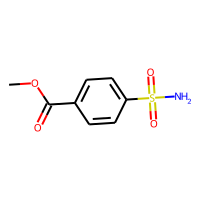
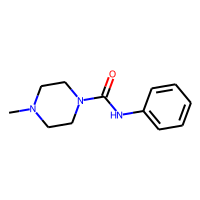
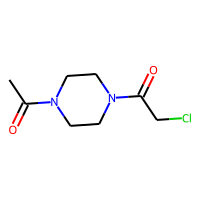
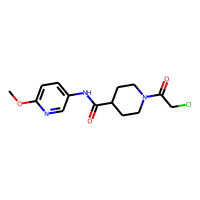
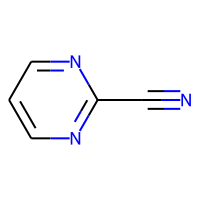
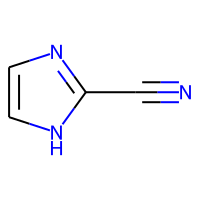
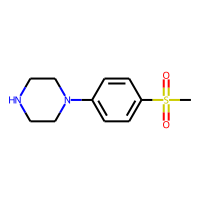

In [4]:
df = pd.read_excel("https://www.diamond.ac.uk/dam/jcr:cb44b3b1-fb14-4376-b172-ce45cbd66b48/Mpro%20full%20XChem%20screen%20-%20hits%20summary%20-%20ver-2020-06-12.xlsx")
AddMoleculeColumnToFrame(df, smilesCol="Compound SMILES")
df

## Select fragment screen subset
Structural data is available through these links:

* [All Fragment Screen Hits](https://www.diamond.ac.uk/dam/jcr:4c19c5bc-d35b-4e50-8e7d-c7b9ad1515d7/Mpro_XChem_PDB_20200612.7z)
* [Non-covalent fragment hits in the active site](https://www.diamond.ac.uk/dam/jcr:b65e692d-68c9-4344-80ec-67686d775fe8/Mpro_XChem_screen_active_site_11-May-2020.zip)
* [Covalently-bound fragment hits in the active site](https://www.diamond.ac.uk/dam/jcr:8cb74d26-2bf9-4ba1-9c03-4b1f2a343357/Mpro_XChem_screen_covalents_16-May-2020.zip)
* [All other fragment hits including the dimer interface, on the surface, and in crystal contacts](https://www.diamond.ac.uk/dam/jcr:67b33ee1-26b0-43fb-b8e0-ec68e5030e35/Mpro_XChem_screen_other_11-May-2020.zip)

We are interested in the subset that consists of non-covalent ligands:

In [5]:
# If already downloaded, they should be here:
pdbs = list((DATA / "Mpro_XChem_screen_active_site_11-May-2020").glob("*.pdb"))

if not pdbs:
    url = "https://www.diamond.ac.uk/dam/jcr:b65e692d-68c9-4344-80ec-67686d775fe8/Mpro_XChem_screen_active_site_11-May-2020.zip"
    with urlopen(url) as f:
        with BytesIO(f.read()) as b, ZipFile(b) as z:
            z.extractall(DATA)
    # Reassign now
    pdbs = list((DATA / "Mpro_XChem_screen_active_site_11-May-2020").glob("*.pdb"))
    assert pdbs, "Couldn't find downloaded PDB structures!"

print(f"Data set contains {len(pdbs)} pdb structures.")

Data set contains 23 pdb structures.


## Visual data inspection

Use [nglviewer](http://nglviewer.org/)to visualize the structures and fragments.

In [19]:
view = nv.NGLWidget() 
for pdb in pdbs[:10]: # display first 10 only
    structure = nv.adaptor.FileStructure(str(pdb))
    comp = view.add_component(structure, default_representation=False)
    comp.add_cartoon()
    comp.add_ball_and_stick("LIG")
view.center("LIG")
view

NGLWidget()

In [20]:
view.render_image(factor=1, trim=True, transparent=True, antialias=True);

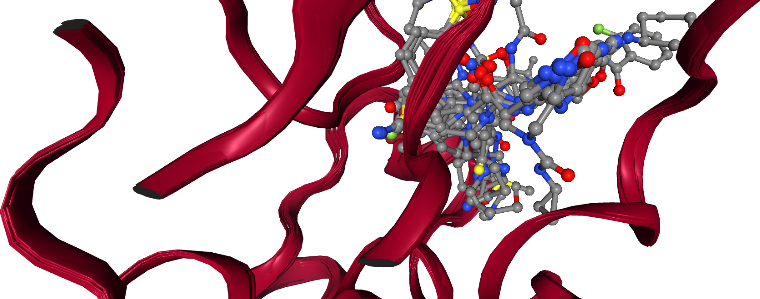

In [21]:
view._display_image()

As depicted above, the proteins are prealigned and ligands occupy the same binding site (symetrically duplicated).

# Generating proteil-ligand interaction statistics

## Ingesting data in `plipify` 
* Store the data as plipify structure files
* Generate interaction fingerprints

In [25]:
structures = [Structure.from_pdbfile(str(path), ligand_name="LIG") for path in tqdm(pdbs)]

print(f"Data set contains {len(structures)} plipify structures.")

  0%|          | 0/23 [00:00<?, ?it/s]

Data set contains 23 plipify structures.


In [28]:
print(f"Per structure information:\n {structures[0]}")

Per structure information:
 <Structure with 304 residues, 4 ligands (3 of which were ignored) and 1 characterized binding sites. (loaded from file `/home/andrea/devel/py/plipify/projects/01/data/XChem/Mpro_XChem_screen_active_site_11-May-2020/Mpro-x0072_0.pdb`)>


In [29]:
fp = InteractionFingerprint().calculate_fingerprint(
        structures,
        labeled=True, 
        as_dataframe=True, 
        remove_non_interacting_residues=True
    )

# Drop null interaction types
fp = fp.loc[:, (fp != 0).any(axis=0)]

# Color the resulting data frame
fp.style.background_gradient(axis=None, cmap="YlGnBu")

,hydrophobic,hbond-don,hbond-acc,waterbridge,saltbridge,pistacking
25,3,0,0,0,0,0
41,2,2,1,0,0,6
44,0,0,1,0,0,0
49,1,0,0,0,0,0
140,1,0,0,0,0,0
142,1,1,0,1,0,0
143,0,1,0,0,0,0
144,0,2,1,0,0,0
145,0,1,0,0,0,0
163,0,0,2,0,0,0


## Different display formats

Besides the dataframe display, 'plipify' features different output formats for analysing the interaction statistics
* Barplot
* Heatmap
* Table

### Barplot

In [30]:
fingerprint_barplot(fp)

### Heatmap

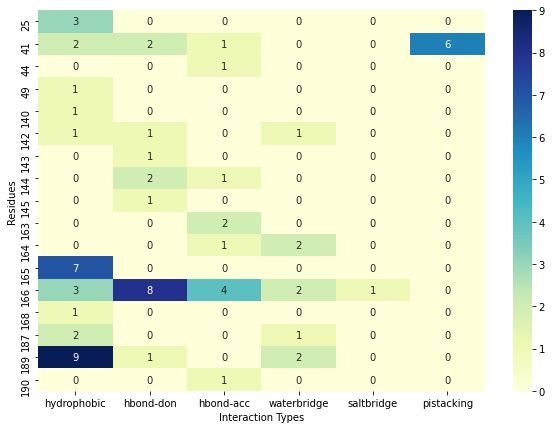

In [31]:
fingerprint_heatmap(fp, cmap="YlGnBu");

### Table

In [39]:
fingerprint_table(fp)

HTML(value='\n    <style>\n    \n    table.plipify-legend {\n        text-align: center;\n        color: #fff;…

# Generating 3D figures with interaction information

The interactions can also be inspected in 3D using enhanced NGLView visualization. 

This will:
* Show involved sidechains
* Display the interactions as lines
* Patch the tooltips so you can inspect which interactions were involved

In [34]:
view = fingerprint_nglview(fp, structures[0])
view.center("LIG")
view

NGLWidget()

In [35]:
view.render_image(factor=1, trim=True, transparent=True, antialias=True);

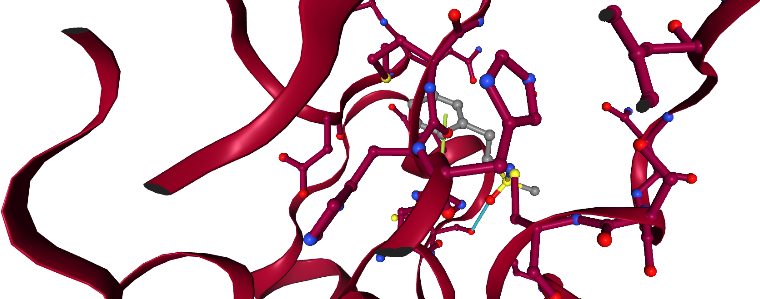

In [36]:
view._display_image()